<a href="https://colab.research.google.com/github/damnhuquynhvn-oss/thuchanhdeeplearning/blob/main/Lab02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 654k/654k [00:00<00:00, 98.7MB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/nguyentiennhan/vietnam-housing-dataset-2024/versions/8
                                             Address  Area  Frontage  \
0  Dự án The Empire - Vinhomes Ocean Park 2, Xã L...  84.0       NaN   
1  Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...  60.0       NaN   
2  Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...  90.0       6.0   
3  Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...  54.0       NaN   
4   Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh  92.0       NaN   

   Access Road House direction Balcony direction  Floors  Bedrooms  Bathrooms  \
0          NaN             NaN               NaN     4.0       NaN        NaN   
1          NaN             NaN               NaN     5.0       NaN        NaN   
2         13.0      Đông - Bắc        Đông - Bắc     5.0       NaN        NaN   
3          3.5       Tây - Nam         Tây - Nam     2.0       2.0        3.0   
4          NaN      Đông - Nam        Đôn


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
605/605 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0370 - mae: 0.1564 - val_loss: 0.0346 - val_mae: 0.1520
Epoch 2/100
605/605 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0341 - mae: 0.1503 - val_loss: 0.0333 - val_mae: 0.1482
Epoch 3/100
605/605 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0336 - mae: 0.1486 - val_loss: 0.0329 - val_mae: 0.1465
Epoch 4/100
605/605 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0329 - mae: 0.1470 - val_loss: 0.0324 - val_mae: 0.1456
Epoch 5/100
605/605 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0328 - mae: 0.1464 - val_loss: 0.0322 - val_mae: 0.1448
Epoch 6/100
605/605 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0326 - mae: 0.1458 - val_loss: 0.0339 - val_mae: 0.1483
Epoch 7/100
605/605 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0325 - mae: 0.1456 - val_loss: 0.0324 - val_mae: 0.1451
Epoch 8/100
605/605 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0323 - mae: 0.1451 - val_loss: 0.0325 - val_mae: 0.1444
Epoch 9/100
605/605 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/

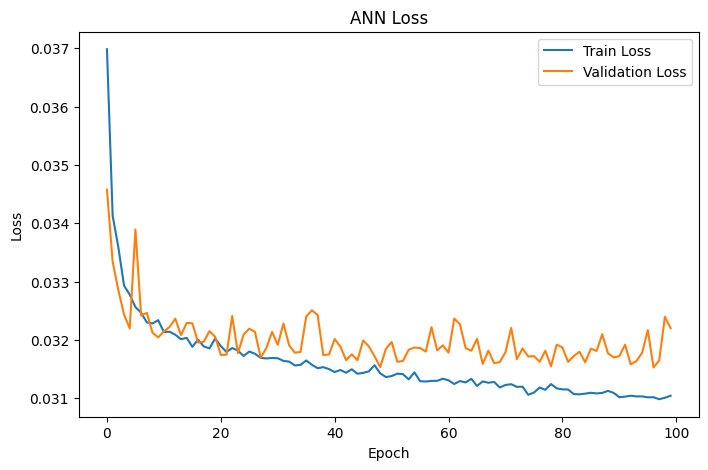

In [1]:
# =====================================================
# ANN REGRESSION - VIETNAM HOUSING DATASET
# =====================================================

!pip -q install kagglehub

import kagglehub
import pandas as pd
import numpy as np
import os
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

import matplotlib.pyplot as plt

# =====================================================
# 1. DOWNLOAD DATASET
# =====================================================

path = kagglehub.dataset_download(
    "nguyentiennhan/vietnam-housing-dataset-2024"
)

print("Dataset path:", path)

csv_files = [
    f for f in os.listdir(path)
    if f.endswith(".csv")
]

csv_path = os.path.join(path, csv_files[0])

df = pd.read_csv(csv_path)

print(df.head())

# =====================================================
# 2. CLEAN DATA
# =====================================================

df.columns = df.columns.str.strip()

# Area
if 'Area' in df.columns:
    df['Area'] = pd.to_numeric(
        df['Area'],
        errors='coerce'
    )

# Price
if 'Price' in df.columns:

    df = df[df['Price'] != 'Thỏa thuận']

    df['Price'] = pd.to_numeric(
        df['Price'],
        errors='coerce'
    )

# Numerical columns
cols = [
    'Area',
    'Bedrooms',
    'Bathrooms',
    'Floors',
    'Price'
]

for col in cols:

    if col in df.columns:

        df[col] = pd.to_numeric(
            df[col],
            errors='coerce'
        )

        df[col] = df[col].fillna(
            df[col].median()
        )

# remove extreme floor values
if 'Floors' in df.columns:
    df = df[df['Floors'] <= 20]

print("\nDataset shape:", df.shape)

# =====================================================
# 3. FEATURE / LABEL
# =====================================================

X = df[
    [
        'Area',
        'Bedrooms',
        'Bathrooms',
        'Floors'
    ]
]

y = df['Price']

# =====================================================
# 4. TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

# =====================================================
# 5. SCALE DATA
# =====================================================

x_scaler = MinMaxScaler()

X_train_scaled = x_scaler.fit_transform(X_train)

X_test_scaled = x_scaler.transform(X_test)

y_scaler = MinMaxScaler()

y_train_scaled = y_scaler.fit_transform(
    y_train.values.reshape(-1,1)
)

y_test_scaled = y_scaler.transform(
    y_test.values.reshape(-1,1)
)

# =====================================================
# 6. BUILD ANN MODEL
# =====================================================

model = tf.keras.Sequential([

    tf.keras.layers.Dense(
        64,
        activation='relu',
        input_shape=(4,)
    ),

    tf.keras.layers.Dense(
        32,
        activation='relu'
    ),

    tf.keras.layers.Dense(
        16,
        activation='relu'
    ),

    tf.keras.layers.Dense(
        1
    )
])

# =====================================================
# 7. COMPILE
# =====================================================

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

# =====================================================
# 8. TRAIN
# =====================================================

history = model.fit(

    X_train_scaled,
    y_train_scaled,

    epochs=100,

    batch_size=32,

    validation_split=0.2,

    verbose=1
)

# =====================================================
# 9. EVALUATE
# =====================================================

loss, mae = model.evaluate(
    X_test_scaled,
    y_test_scaled,
    verbose=0
)

print("\nMSE =", loss)
print("MAE =", mae)

# =====================================================
# 10. PREDICT
# =====================================================

pred_scaled = model.predict(
    X_test_scaled
)

pred_price = y_scaler.inverse_transform(
    pred_scaled
)

actual_price = y_test.values.reshape(-1,1)

mse_real = mean_squared_error(
    actual_price,
    pred_price
)

mae_real = mean_absolute_error(
    actual_price,
    pred_price
)

print("\nREAL MSE =", mse_real)
print("REAL MAE =", mae_real)

# =====================================================
# 11. SHOW RESULT
# =====================================================

result = pd.DataFrame({

    "Actual Price": actual_price.flatten(),

    "Predicted Price": pred_price.flatten()
})

print("\nFirst 10 Predictions")

print(result.head(10))

# =====================================================
# 12. LOSS GRAPH
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN Loss")

plt.legend()

plt.show()